In [13]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

In [15]:
ntrain = 25
nval = 13
test = np.arange(38,50)

trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

[array([12, 33,  1,  2, 21, 11,  4, 30, 32, 36,  0, 10, 22, 34, 27,  8, 16,
        23,  6, 13, 25, 35, 17, 19, 29]),
 array([37, 18, 24,  5, 28, 26,  7, 31, 20, 14, 15,  9,  3]),
 array([38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])]

In [2]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

latsel = 40
lonsel = 250
ssp = "245" 

historical_era = [1960,2000]
tpercentile = 90
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 3

# data params
outres = 10
timerange = [1950,2080]
filefront = "MPI_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,]

data/MPI_annualmean_245_tos.pkl


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:362: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


(array([ 2.,  4.,  5.,  5.,  7., 10.,  7.,  5.,  3.,  2.]),
 array([291.8527045 , 292.00019099, 292.14767748, 292.29516398,
        292.44265047, 292.59013696, 292.73762345, 292.88510994,
        293.03259643, 293.18008293, 293.32756942]),
 <BarContainer object of 10 artists>)

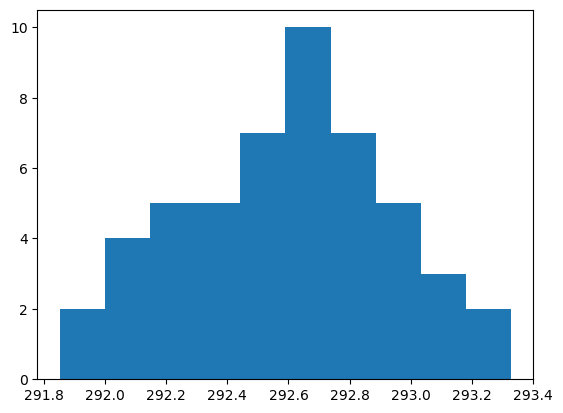

In [3]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "ssp": ssp,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

#get the data

AllData = DataHolder.MPIInputOutput(params)

alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era,inputlength,outputavgtime, tpercentile, latsel, lonsel)

inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)

plt.hist(AllData.onesigmas)

In [4]:
import glob
glob.glob("models/"+filefront+"avgtime"+str(outputavgtime)+"_ssp"+ssp+"_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_*.pt")

['models/MPI_avgtime3_ssp245_per90_lat40_lon250_seed47621498.pt',
 'models/MPI_avgtime3_ssp245_per90_lat40_lon250_seed71856281.pt',
 'models/MPI_avgtime3_ssp245_per90_lat40_lon250_seed62469869.pt']

Seed  62469869  val accuracy:  0.8707175177763413
Seed  71856281  val accuracy:  0.8584356819650937
Seed  47621498  val accuracy:  0.8694246929541047
GMT only val accuracy:  0.865546218487395


(2000.0, 2040.0)

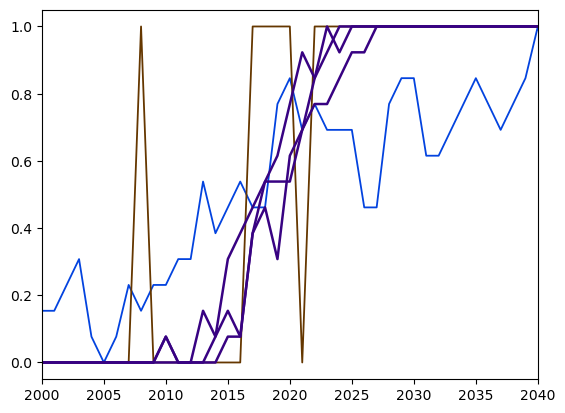

In [12]:

outputvalclass = np.argmax(outputval.numpy(),axis=1)

#baseline of beating gmt, need to get gmt

gmtallmembers = AllData.alloutput
avgeffectofGMT_train = np.mean(gmtallmembers[:25], axis=0)
avgeffectofGMTabs = np.round(avgeffectofGMT_train, decimals=0)
avgeffectofGMTval = np.tile(avgeffectofGMTabs, (len(trainvaltest[1])))

avgeffectofGMT_test = np.mean(gmtallmembers[25:38], axis=0)

yearvec = np.arange(timerange[0]+inputlength, timerange[1]-outputavgtime+2)
gmtplot = np.reshape(inputtrainGMT.numpy().squeeze(),(len(trainvaltest[0]),len(yearvec)))
gmtplot = np.mean(gmtplot,axis=0)

plt.subplot(1,1,1)
plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

allpred = []

for iseed, seed in enumerate(seedlist):

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+filefront+"avgtime"+str(outputavgtime)+"_ssp"+ssp+"_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True))
    cnn.eval()

    with torch.no_grad():
        predval = cnn(inputval, inputvalGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    allpred.append(predval.numpy())
    acc = np.mean(predvalclass == outputvalclass)
    print("Seed ", str(seed), " val accuracy: ", str(acc))


    predseed = allpred[iseed]
    predseed = np.argmax(predseed, axis=1)
    predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    predseedmean = np.mean(predseed, axis=0)
    plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))


gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
print("GMT only val accuracy: ", str(gmtonlyacc))

plt.xlim(2000,2040)


In [6]:
gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
print("GMT only val accuracy: ", str(gmtonlyacc))


GMT only val accuracy:  0.865546218487395


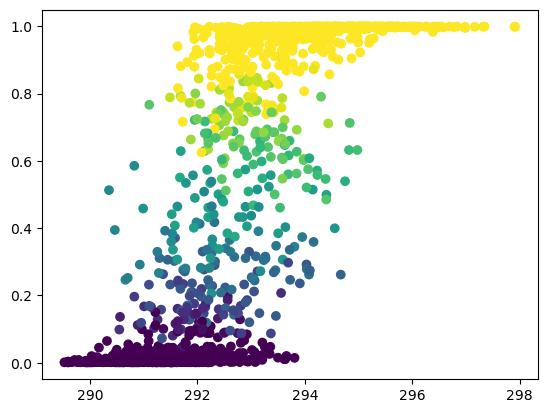

In [7]:
plt.scatter(AllData.truesummer[25:38].flatten(),allpred[0][:,1],c=inputvalGMT.numpy(),vmin=0.3,vmax=0.8)

In [8]:
AllData.input_annualmean.shape

(50, 131, 45, 90)

In [9]:
imp.reload(DataHolder)

plotnum = 0

outputavgtime = 3

plt.figure(figsize=(12,8))

for ssp in ssplist:
    for tpercentile in [90]:

        params = {
            "inputlength": inputlength,
            "outputavgtime": outputavgtime,
            "outres": outres,
            "ssp": ssp,
            "timerange": timerange,
            "filefront": filefront,
            "inres": inres,
            "inputvar":inputvar,
            "outputvar":outputvar,
            "seedlist": seedlist,
        }

        #get the data

        AllData = DataHolder.MPIInputOutput(params)

        alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era, inputlength, outputavgtime,  tpercentile, latsel, lonsel)

        inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
        inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
        inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)

        
        outputval = torch.argmax(outputval, dim=1).numpy()

        #baseline of beating gmt, need to get gmt

        gmtallmembers = AllData.alloutput
        avgeffectofGMT = np.mean(gmtallmembers[:25], axis=0)
        avgeffectofGMTabs = np.round(avgeffectofGMT, decimals=0)
        avgeffectofGMTval = np.tile(avgeffectofGMTabs, (len(trainvaltest[1])))

        allpred = []

        for iseed, seed in enumerate(seedlist):

            cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
            fileout = "models/"+filefront+"ssp"+ssp+"_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
            cnn.load_state_dict(torch.load(fileout, weights_only=True))
            cnn.eval()

            with torch.no_grad():
                predval = cnn(inputval, inputvalGMT)

            predvalclass = torch.argmax(predval, dim=1).numpy()
            allpred.append(predval.numpy())
            acc = np.mean(predvalclass == outputval)
            print("Seed ", str(seed), " val accuracy: ", str(acc))

        gmtonlyacc = np.mean(avgeffectofGMTval == outputval)
        print("GMT only val accuracy: ", str(gmtonlyacc))


        yearvec = np.arange(timerange[0]+inputlength, timerange[1]-outputavgtime+2)

        gmtplot = np.reshape(inputtrainGMT.numpy().squeeze(),(len(trainvaltest[0]),len(yearvec)))
        gmtplot = np.mean(gmtplot,axis=0)


        plt.subplot(2,1,plotnum+1)
        plt.plot(yearvec,avgeffectofGMT,color='xkcd:blue',label='GMT only',linewidth=1.3)
        # plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)
        # plt.plot(yearvec,gmtplot)

        for iseed, seed in enumerate(seedlist):
            predseed = allpred[iseed]
            predseed = np.argmax(predseed, axis=1)
            predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

            predseedmean = np.mean(predseed, axis=0)
            plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

            for i in range(len(trainvaltest[2])):
                plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

        plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

        plotnum+=1 
plt.tight_layout()
plt.show()


NameError: name 'ssplist' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
timerange

[1950, 2080]

In [ ]:
filefront

'MPI_'

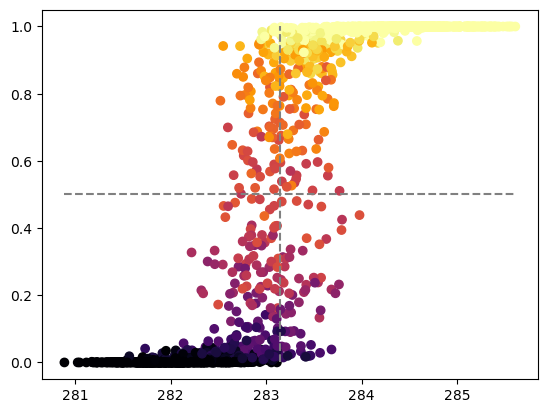

In [ ]:
plt.scatter(AllData.truesummer[25:38].flatten(),allpred[1][:,1],c=inputvalGMT.numpy(),cmap='inferno',vmin=0,vmax=0.8)
avgextreme = np.mean(AllData.onesigmas,axis=0)
plt.vlines(avgextreme,0,1,color='grey',linestyle='--')
plt.hlines(0.5,np.min(AllData.truesummer[25:38]),np.max(AllData.truesummer[25:38]),color='grey',linestyle='--')

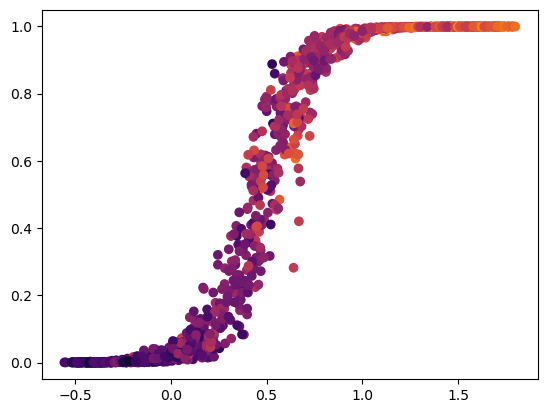

In [ ]:
plt.scatter(inputvalGMT.numpy(),allpred[1][:,1],c=AllData.truesummer[25:38].flatten(),cmap='inferno')

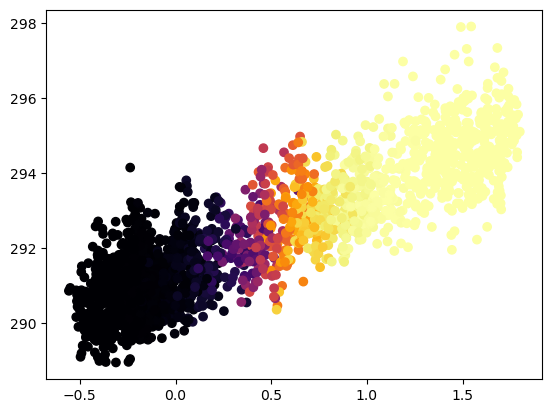

In [ ]:
plt.scatter(inputvalGMT.numpy(),AllData.truesummer[25:38].flatten(),c=allpred[1][:,1],cmap='inferno')

In [ ]:
a = np.arange(7340)

np.percentile(a,100)

7339.0